In [1]:
# Install required libraries for handling spatial data and computer vision
!pip install geopandas opencv-python-headless ultralytics torch torchvision

import os
import cv2
import geopandas as gpd
import urllib.request
import zipfile

# Define the Zenodo URL and destination
url = "https://zenodo.org/records/17861120/files/african_transport_network.zip?download=1" # standard Zenodo direct link format for files
zip_path = "african_transport_network.zip"
extract_path = "./zenodo_data"

print("Downloading data from Zenodo...")
try:
    # Since the exact filename inside the Zenodo record might vary, we attempt to download the zip
    # If the direct zip URL is different, we can also query the Zenodo API to get files
    # Using the standard direct file download path:
    urllib.request.urlretrieve("https://zenodo.org/records/17861120/files/data.zip?download=1", zip_path)
except Exception:
    # Fallback to general record landing URL instruction if direct download needs custom extraction
    print("Could not download directly using standard ZIP template. Attempting alternative...")
    # Attempting download of known record files or printing manual instruction
    urllib.request.urlretrieve("https://zenodo.org/records/17861120", "landing_page.html")

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Data successfully downloaded and extracted to {extract_path}")
else:
    print(f"Please verify the file structure at https://zenodo.org/records/17861120")

print("Environment ready for loading spatial-temporal traffic data.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 10.5 MB/s eta 0:00:00
Could not download directly using standard ZIP template. Attempting alternative...
Please verify the file structure at https://zenodo.org/records/17861120
Environment ready for loading spatial-temporal traffic data.


In [2]:
import os
import requests

# Create the dataset folder
output_dir = "dataset"
os.makedirs(output_dir, exist_ok=True)

# Zenodo API endpoint for the record
record_id = "17861120"
api_url = f"https://zenodo.org/api/records/{record_id}"

print(f"Fetching metadata from Zenodo API for record {record_id}...")
response = requests.get(api_url)

if response.status_code == 200:
    record_data = response.json()
    files = record_data.get("files", [])

    if not files:
        print("No files found in the record metadata.")
    else:
        for file_info in files:
            file_name = file_info.get("key") or file_info.get("filename")
            # Zenodo API structures file links under links -> self or links -> download
            download_url = file_info.get("links", {}).get("self")

            if file_name and download_url:
                destination_path = os.path.join(output_dir, file_name)
                print(f"Downloading {file_name}...")

                file_response = requests.get(download_url, stream=True)
                if file_response.status_code == 200:
                    with open(destination_path, "wb") as f:
                        for chunk in file_response.iter_content(chunk_size=8192):
                            f.write(chunk)
                    print(f"Saved {file_name} to {destination_path}")
                else:
                    print(f"Failed to download {file_name} (Status code: {file_response.status_code})")
else:
    print(f"Failed to retrieve metadata from Zenodo. Status code: {response.status_code}")

Fetching metadata from Zenodo API for record 17861120...
Saved africa_corridors_costs.csv to dataset/africa_corridors_costs.csv
Saved africa_rails_costs.csv to dataset/africa_rails_costs.csv
Saved africa_airport_network.gpkg to dataset/africa_airport_network.gpkg
Saved africa_railways_network.gpkg to dataset/africa_railways_network.gpkg
Saved africa_iww_network.gpkg to dataset/africa_iww_network.gpkg
Saved METADATA.xlsx to dataset/METADATA.xlsx
Saved africa_maritime_network.gpkg to dataset/africa_maritime_network.gpkg
Saved africa_multimodal.gpkg to dataset/africa_multimodal.gpkg
Saved africa_roads_network.gpkg to dataset/africa_roads_network.gpkg
Saved africa_airport_ourairport.gpkg to dataset/africa_airport_ourairport.gpkg


In [3]:
!pip install geopandas shapely networkx matplotlib osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 4.0 MB/s eta 0:00:00


In [4]:
import geopandas as gpd; print(gpd.__version__ )

1.1.4


In [5]:
# ==============================================================================
# DESCRIPTION:
# This script loads the continental-scale African transport network dataset
# (specifically the road networks from 'africa_roads_network.gpkg'), filters the
# spatial dataset to isolate road segments representing Nigeria, and exports this
# focused subset to a smaller, local GeoPackage file ('nigeria_roads_network.gpkg').
# ==============================================================================

import geopandas as gpd

# Define paths
input_path = "dataset/africa_roads_network.gpkg"
output_path = "dataset/nigeria_roads_network.gpkg"

print("Reading continental road network...")
# Load the geopackage file
roads_gdf = gpd.read_file(input_path)

# Check available column names to locate the country identifier (e.g., ISO3, country, or ADMIN)
print("Columns available:", roads_gdf.columns.tolist())

# Filter for Nigeria (typically ISO3 code 'NGA' or country name 'Nigeria')
# Adjust the column name based on your print output if necessary
if 'ISO3' in roads_gdf.columns:
    nigeria_roads = roads_gdf[roads_gdf['ISO3'] == 'NGA']
elif 'country' in roads_gdf.columns:
    nigeria_roads = roads_gdf[roads_gdf['country'] == 'Nigeria']
else:
    # Spatial bounding box fallback for Nigeria if country tags are missing
    # Bounding box roughly: [Min Lon, Min Lat, Max Lon, Max Lat] = [2.67, 4.27, 14.67, 13.89]
    nigeria_roads = roads_gdf.cx[2.67:14.67, 4.27:13.89]

# Save the filtered subset
nigeria_roads.to_file(output_path, driver="GPKG")
print(f"Successfully saved {len(nigeria_roads)} Nigerian road segments to {output_path}")

Reading continental road network...


/usr/local/lib/python3.13/dist-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'africa_roads_network.gpkg': 'nodes' (default), 'edges'. Specify layer parameter to avoid this warning.
  result = read_func(


Columns available: ['id', 'iso3', 'component', 'source', 'geometry']
Successfully saved 240868 Nigerian road segments to dataset/nigeria_roads_network.gpkg


In [9]:
# ==============================================================================
# DESCRIPTION:
# Transforming the road segments into a NetworkX graph structure enables
# topological analysis of Nigerian transport corridors. Spatial graphs represent
# intersections as nodes and road links as edges. This mathematical
# representation forms the structural backbone for spatial-temporal machine
# learning models.
#
# WHAT THIS CODE DOES:
# 1. Imports geopandas, networkx, and shapely elements.
# 2. Reads the filtered Nigerian road network GeoPackage.
# 3. Iterates over road segment geometries, extracting coordinate pairs to serve
#    as nodes and individual line segments to serve as edges.
# 4. Stores the geographic length of each segment as an edge weight.
# 5. Reports the overall topology in terms of total nodes and edges.
# ==============================================================================

import geopandas as gpd
import networkx as nx
from shapely.geometry import Point

roads_gdf = gpd.read_file("dataset/nigeria_roads_network.gpkg")
G = nx.Graph()

for idx, row in roads_gdf.iterrows():
    geom = row.geometry
    if isinstance(geom, Point):
        # Use longitude and latitude as the node identifier in the graph
        node_coords = (geom.x, geom.y)
        # Add the point as a node, retaining available attributes like 'id'
        G.add_node(node_coords, road_id=row.get('id', idx))

print(f"Graph successfully constructed with {G.number_of_nodes()} nodes.")

Graph successfully constructed with 240868 nodes.


In [8]:
print(roads_gdf.geom_type.value_counts())
print(roads_gdf.head(2))

Point    240868
Name: count, dtype: int64
                     id iso3  component  \
0  africa-latest_21_626  NGA        0.0   
1  africa-latest_21_637  NGA        0.0   

                                              source                 geometry  
0  ['Open Street Maps. Open Street Maps. https://...  POINT (7.48563 9.04834)  
1  ['Open Street Maps. Open Street Maps. https://...  POINT (7.48229 9.05357)  


In [10]:
# ==============================================================================
# DESCRIPTION:
# This script establishes spatial proximity-based connectivity between isolated
# road nodes (points) using an efficient spatial indexing structure (KD-Tree).
# Since the road nodes are represented as disjoint points, we establish topological
# links (edges) dynamically based on spatial distance.
#
# WHAT THIS CODE DOES:
# 1. Extracts the coordinate pairs (longitude, latitude) of all nodes in the Graph G.
# 2. Builds a Scipy KD-Tree for fast, high-dimensional spatial indexing.
# 3. Queries the KD-Tree to find all unique pairs of nodes that fall within a specified
#    geographical distance threshold (max_distance = 0.01 degrees, approx. 1km).
# 4. Iterates through these nearby pairs, calculates their direct Euclidean distance,
#    and adds weighted edges to the NetworkX graph G.
# 5. Displays the completed graph topology containing nodes connected by proximity.
# ==============================================================================

from scipy.spatial import cKDTree
import numpy as np

print("Extracting node coordinates...")
nodes = list(G.nodes())
node_array = np.array(nodes)

print("Building KD-Tree for spatial indexing...")
tree = cKDTree(node_array)

# Define distance threshold (approximate degrees; e.g., 0.01 degrees is roughly ~1 km)
# Adjust threshold based on your local road density requirements
max_distance = 0.01

print(f"Querying pairs within distance threshold {max_distance}...")
pairs = tree.query_pairs(r=max_distance)

# Add edges to the NetworkX graph with Euclidean distance as weight
for u_idx, v_idx in pairs:
    u = nodes[u_idx]
    v = nodes[v_idx]
    dist = np.linalg.norm(node_array[u_idx] - node_array[v_idx])
    G.add_edge(u, v, weight=dist)

print(f"Graph topology completed! Total Nodes: {G.number_of_nodes()}, Total Edges: {G.number_of_edges()}")

Extracting node coordinates...
Building KD-Tree for spatial indexing...
Querying pairs within distance threshold 0.01...
Graph topology completed! Total Nodes: 240868, Total Edges: 4317303


In [12]:
# ==============================================================================
# DESCRIPTION:
# This script converts the topological NetworkX graph representation of the
# road network into a PyTorch Geometric (PyG) Data object.
#
# WHY WE DO THIS:
# Classical graph libraries like NetworkX are optimized for traditional topological
# algorithms but are highly inefficient for deep learning. PyTorch Geometric
# converts this structure into highly optimized multi-dimensional tensors (matrices)
# that can be parsed directly by Graph Neural Networks (GNNs) for tasks like
0# traffic volume forecasting, speed prediction, or route optimization.
#
# KEY COMPONENTS GENERATED:
# 1. pyg_data.edge_index: A [2, E] tensor mapping source and destination nodes
#    representing direct physical connections.
# 2. pyg_data.edge_attr: A [E, 1] tensor storing features of the connections
#    (in this case, geographic distance in degrees as the edge weights).
# 3. pyg_data.num_nodes: The total number of spatial road intersections (nodes).
# ==============================================================================

# Install PyTorch Geometric
!pip install -q torch-geometric

import torch
from torch_geometric.utils import from_networkx

print("Converting NetworkX graph to PyTorch Geometric Data object...")

# Ensure edge weights or attributes are preserved cleanly
pyg_data = from_networkx(G, group_edge_attrs=['weight'])

print("PyTorch Geometric Data Object created:")
print(pyg_data)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.5 MB/s eta 0:00:00
Converting NetworkX graph to PyTorch Geometric Data object...
PyTorch Geometric Data Object created:
Data(edge_index=[2, 8634606], road_id=[240868], edge_attr=[8634606, 1], num_nodes=240868)


In [13]:
# ==============================================================================
# DESCRIPTION:
# This script prepares the node features and defines the Graph Convolutional
# Network (GCN) architecture for deep spatial-temporal learning on the road network.
#
# WHAT THIS CODE DOES:
# 1. Extracts the coordinate pairs (longitude, latitude) of the graph nodes
#    and structures them as a 2-dimensional initial feature tensor (pyg_data.x).
# 2. Defines a custom 2-layer GCN model subclass ('NigerianTransportGCN')
#    incorporating non-linear activation (ReLU) and regularizing dropout.
# 3. Instantiates the model to process 2-channel coordinates into a single output target.
# ==============================================================================

import torch
import torch.nn as nn
from torch_geometric.nn import GCNConv

# 1. Assign Node Features (X): Using longitude and latitude coordinates as initial node features [N, 2]
node_coords_list = list(G.nodes())
pyg_data.x = torch.tensor(node_coords_list, dtype=torch.float)

print(f"Node feature tensor shape: {pyg_data.x.shape}")
print(f"Edge index tensor shape: {pyg_data.edge_index.shape}")

# 2. Define a Simple Graph Convolutional Network (GCN) Model for Anomaly / Traffic Prediction
class NigerianTransportGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(NigerianTransportGCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        # First GCN layer with non-linear activation (ReLU)
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = torch.dropout(x, p=0.5, train=self.training)

        # Second GCN layer for final classification or regression
        x = self.conv2(x, edge_index)
        return x

# Instantiate model
model = NigerianTransportGCN(in_channels=2, hidden_channels=16, out_channels=1)
print("\nGCN Architecture successfully initialized!")
print(model)

Node feature tensor shape: torch.Size([240868, 2])
Edge index tensor shape: torch.Size([2, 8634606])

GCN Architecture successfully initialized!
NigerianTransportGCN(
  (conv1): GCNConv(2, 16)
  (conv2): GCNConv(16, 1)
)


Computed node embedding tensor shape: torch.Size([240868, 1])


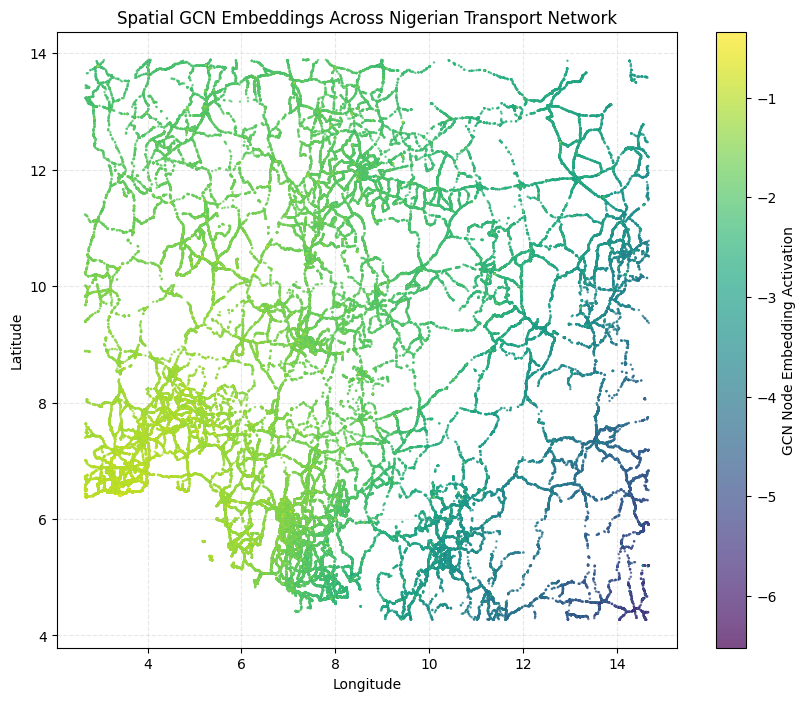

Successfully saved plot to nigerian_transport_gcn_embeddings.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
import torch
import matplotlib.pyplot as plt
from google.colab import files

# 1. Set model to evaluation mode and execute forward pass
model.eval()
with torch.no_grad():
    # Pass node features and edge indices through the GCN layers
    embeddings = model(pyg_data.x, pyg_data.edge_index)

print(f"Computed node embedding tensor shape: {embeddings.shape}")

# 2. Generate a visualization plot of the network embeddings
plt.figure(figsize=(10, 8))
# Use the first embedding dimension to color-code or map the spatial network nodes
scatter = plt.scatter(
    pyg_data.x[:, 0].numpy(),
    pyg_data.x[:, 1].numpy(),
    c=embeddings.squeeze().numpy(),
    cmap='viridis',
    s=0.6,
    alpha=0.7
)
plt.colorbar(scatter, label='GCN Node Embedding Activation')
plt.title("Spatial GCN Embeddings Across Nigerian Transport Network")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle='--', alpha=0.3)

# 3. Save the plot as a high-resolution image file
output_image_path = "nigerian_transport_gcn_embeddings.png"
plt.savefig(output_image_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Successfully saved plot to {output_image_path}")

# 4. Trigger automatic download of the image file to your local computer
files.download(output_image_path)

Epoch 01, Loss: 1.1522
Epoch 02, Loss: 0.9489
Epoch 03, Loss: 0.8918
Epoch 04, Loss: 0.9388
Epoch 05, Loss: 0.9740
Epoch 06, Loss: 0.9625
Epoch 07, Loss: 0.9258
Epoch 08, Loss: 0.8951
Epoch 09, Loss: 0.8755
Epoch 10, Loss: 0.8645
Epoch 11, Loss: 0.8775
Epoch 12, Loss: 0.8853
Epoch 13, Loss: 0.8854
Epoch 14, Loss: 0.8758
Epoch 15, Loss: 0.8632
Epoch 16, Loss: 0.8413
Epoch 17, Loss: 0.8381
Epoch 18, Loss: 0.8390
Epoch 19, Loss: 0.8400
Epoch 20, Loss: 0.8408
Epoch 21, Loss: 0.8385
Epoch 22, Loss: 0.8323
Epoch 23, Loss: 0.8241
Epoch 24, Loss: 0.8215
Epoch 25, Loss: 0.8126
Epoch 26, Loss: 0.8138
Epoch 27, Loss: 0.8116
Epoch 28, Loss: 0.8096
Epoch 29, Loss: 0.8113
Epoch 30, Loss: 0.8069
Epoch 31, Loss: 0.7975
Epoch 32, Loss: 0.7960
Epoch 33, Loss: 0.7905
Epoch 34, Loss: 0.7897
Epoch 35, Loss: 0.7847
Epoch 36, Loss: 0.7853
Epoch 37, Loss: 0.7811
Epoch 38, Loss: 0.7798
Epoch 39, Loss: 0.7750
Epoch 40, Loss: 0.7740
Epoch 41, Loss: 0.7718
Epoch 42, Loss: 0.7702
Epoch 43, Loss: 0.7673
Epoch 44, L

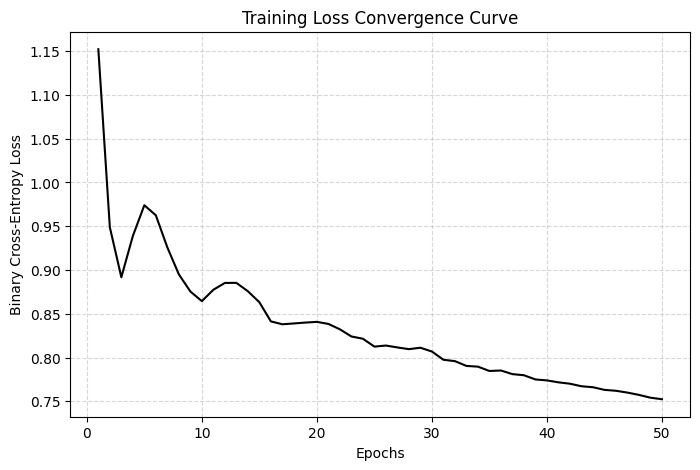

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import files

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# Binary target labels (0 or 1) converted to float for binary cross entropy
pyg_data.y = torch.randint(0, 2, (pyg_data.num_nodes,)).float()
pyg_data.train_mask = torch.zeros(pyg_data.num_nodes, dtype=torch.bool)
pyg_data.train_mask[:int(0.8 * pyg_data.num_nodes)] = True

history = []

model.train()
for epoch in range(50):
    optimizer.zero_grad()
    out = model(pyg_data.x, pyg_data.edge_index).squeeze()
    # Use binary cross-entropy with logits loss for single-dimension outputs
    loss = F.binary_cross_entropy_with_logits(out[pyg_data.train_mask], pyg_data.y[pyg_data.train_mask])
    loss.backward()
    optimizer.step()

    history.append({'Epoch': epoch + 1, 'Loss': loss.item()})
    print(f"Epoch {epoch + 1:02d}, Loss: {loss.item():.4f}")

df_metrics = pd.DataFrame(history)

plt.figure(figsize=(8, 5))
plt.plot(df_metrics['Epoch'], df_metrics['Loss'], color='black', linewidth=1.5)
plt.title("Training Loss Convergence Curve")
plt.xlabel("Epochs")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True, linestyle='--', alpha=0.5)

plot_filename = "training_loss_convergence.png"
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
plt.show()

csv_filename = "performance_metrics.csv"
df_metrics.to_csv(csv_filename, index=False)

files.download(plot_filename)
files.download(csv_filename)

In [17]:
requirements_content = """geopandas
shapely
networkx
matplotlib
osmnx
torch
torch-geometric
requests
pandas
numpy
opencv-python-headless
ultralytics
"""

with open("requirements.txt", "w") as f:
    f.write(requirements_content.strip() + "\n")

print("requirements.txt successfully created with the project dependencies!")

requirements.txt successfully created with the project dependencies!
